In [1]:
# ============================================================
# 01 - EXPLORATION DES DONNÉES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Affichage propre des graphiques
plt.style.use('seaborn-v0_8')
%matplotlib inline

# Lister tous les fichiers disponibles dans data/raw/
fichiers = os.listdir('../data/raw/')
print(f"Nombre de fichiers : {len(fichiers)}")
print("\nFichiers disponibles :")
for f in fichiers:
    print(f" - {f}")

Nombre de fichiers : 13

Fichiers disponibles :
 - AEP_hourly.csv
 - COMED_hourly.csv
 - DAYTON_hourly.csv
 - DEOK_hourly.csv
 - DOM_hourly.csv
 - DUQ_hourly.csv
 - EKPC_hourly.csv
 - FE_hourly.csv
 - NI_hourly.csv
 - PJME_hourly.csv
 - PJMW_hourly.csv
 - pjm_hourly_est.csv
 - PJM_Load_hourly.csv


In [2]:
# ============================================================
# Chargement du fichier principal
# ============================================================

df = pd.read_csv('../data/raw/pjm_hourly_est.csv')

print("=== DIMENSIONS ===")
print(f"Lignes : {df.shape[0]:,}")
print(f"Colonnes : {df.shape[1]}")

print("\n=== PREMIÈRES LIGNES ===")
print(df.head(10))

print("\n=== TYPES DES COLONNES ===")
print(df.dtypes)

print("\n=== STATISTIQUES DE BASE ===")
print(df.describe())

=== DIMENSIONS ===
Lignes : 178,262
Colonnes : 13

=== PREMIÈRES LIGNES ===
              Datetime  AEP  COMED  DAYTON  DEOK  DOM  DUQ  EKPC  FE  NI  \
0  1998-12-31 01:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
1  1998-12-31 02:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
2  1998-12-31 03:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
3  1998-12-31 04:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
4  1998-12-31 05:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
5  1998-12-31 06:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
6  1998-12-31 07:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
7  1998-12-31 08:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
8  1998-12-31 09:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
9  1998-12-31 10:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   

   PJME  PJMW  PJM_Load  
0   NaN   NaN   29309.0  
1   NaN   NaN   28236.0  
2   NaN  

## Choix de la variable cible

Ce dataset contient 12 colonnes de consommation, chacune représentant une région différente du réseau PJM.

Nous devons choisir **une seule série temporelle** comme variable cible pour nos modèles de prévision.

### Critère principal : volume de données

Nos données sont **horaires**. Pour qu'un modèle apprenne correctement les patterns énergétiques (cycles journaliers, hebdomadaires, saisonniers), il doit voir chaque 
cycle se répéter un grand nombre de fois.

| Colonne | Valeurs disponibles | Période couverte |
|---------|-------------------|-----------------|
| PJME | ~145,000 | ~16 ans |
| AEP | ~121,000 | ~14 ans |
| PJM_Load | ~32,000 | ~4 ans |

Avec seulement ~4 ans de données (`PJM_Load`), le modèle ne verrait chaque saison que 4 fois, ce qui n'est pas assez suffisant pour être robuste face à des années atypiques (canicule exceptionnelle, hiver doux, etc.).

### Choix retenu : PJME

`PJME` (PJM Est) est la colonne la plus complète avec ~16 ans de données horaires. Elle couvre la zone Est du réseau PJM, la plus large et la plus représentative. C'est le meilleur compromis entre **volume**, **qualité** et **représentativité**.

## Analyse de la série PJME

On a choisi notre variable cible, l'objectif maintenat est:
1. Isoler la colonne PJME
2. Convertir la date en format datetime
3. Analyser les valeurs manquantes
4. Visualiser la série complète

In [3]:
# ============================================================
# Isolation de PJME et conversion de la date
# ============================================================

# Uniquement les colonnes utiles
df_pjme = df[['Datetime', 'PJME']].copy()

# Conversion de la date (actuellement un string) en vrai datetime
df_pjme['Datetime'] = pd.to_datetime(df_pjme['Datetime'])

# On définit la date comme index (standard pour les séries temporelles)
df_pjme = df_pjme.set_index('Datetime')

# On trie par date 
df_pjme = df_pjme.sort_index()

print("=== APERÇU ===")
print(df_pjme.head(10))

print("\n=== PÉRIODE COUVERTE ===")
print(f"Début : {df_pjme.index.min()}")
print(f"Fin   : {df_pjme.index.max()}")
print(f"Durée : {(df_pjme.index.max() - df_pjme.index.min()).days // 365} ans")

print("\n=== VALEURS MANQUANTES ===")
total = len(df_pjme)
manquantes = df_pjme['PJME'].isna().sum()
print(f"Total lignes      : {total:,}")
print(f"Valeurs manquantes: {manquantes:,}")
print(f"Pourcentage       : {manquantes/total*100:.2f}%")

=== APERÇU ===
                     PJME
Datetime                 
1998-04-01 01:00:00   NaN
1998-04-01 02:00:00   NaN
1998-04-01 03:00:00   NaN
1998-04-01 04:00:00   NaN
1998-04-01 05:00:00   NaN
1998-04-01 06:00:00   NaN
1998-04-01 07:00:00   NaN
1998-04-01 08:00:00   NaN
1998-04-01 09:00:00   NaN
1998-04-01 10:00:00   NaN

=== PÉRIODE COUVERTE ===
Début : 1998-04-01 01:00:00
Fin   : 2018-08-03 00:00:00
Durée : 20 ans

=== VALEURS MANQUANTES ===
Total lignes      : 178,262
Valeurs manquantes: 32,896
Pourcentage       : 18.45%


## Localisation des valeurs manquantes

La base contient 18.45% de valeurs manquantes, ce qui est beaucoup, mais la question clé est :
**où sont-elles ?** En fonction de leurs positions on aura une idée de la cause et on pourra les imputer si nécessaire.

Première valeur non-nulle : 2002-01-01 01:00:00

NaN avant la première valeur : 32,896
NaN après la première valeur : 0


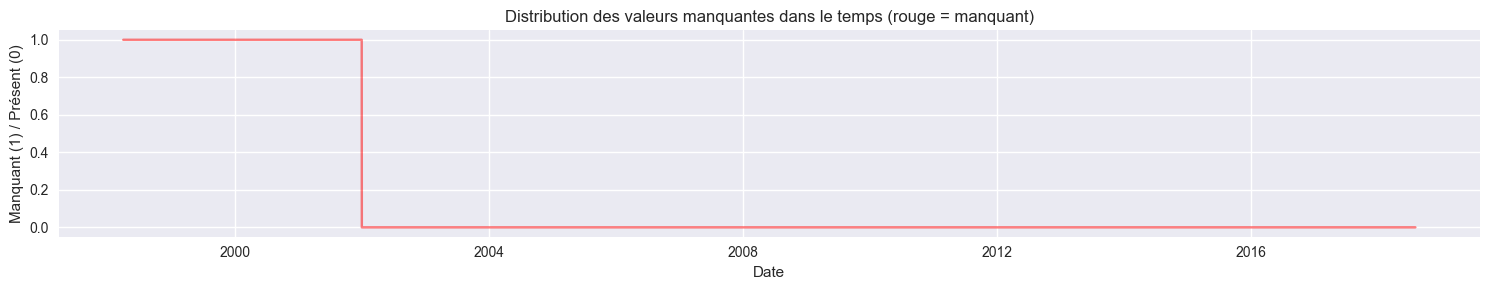

In [4]:
# ============================================================
# Localisation des valeurs manquantes
# ============================================================

# Trouver la première valeur non-nulle
premiere_valeur = df_pjme['PJME'].first_valid_index()
print(f"Première valeur non-nulle : {premiere_valeur}")

# Compter les NaN avant et après cette date
nan_avant = df_pjme.loc[:premiere_valeur, 'PJME'].isna().sum()
nan_apres = df_pjme.loc[premiere_valeur:, 'PJME'].isna().sum()

print(f"\nNaN avant la première valeur : {nan_avant:,}")
print(f"NaN après la première valeur : {nan_apres:,}")

# Visualiser la distribution des NaN dans le temps
plt.figure(figsize=(15, 3))
plt.plot(df_pjme.index, df_pjme['PJME'].isna().astype(int), 
         color='red', alpha=0.5)
plt.title('Distribution des valeurs manquantes dans le temps (rouge = manquant)')
plt.xlabel('Date')
plt.ylabel('Manquant (1) / Présent (0)')
plt.tight_layout()
plt.show()

## Traitement des valeurs manquantes

On vois clairement que les 32,896 NaN sont **entièrement concentrés avant janvier 2002**, il est donc probable que  l'entreprise ne reportait pas encore ses données. Il n'y a aucune valeur manquante après cette date.

On va juste supprimé les lignes antérieures à 2002. 
Aucune imputation n'est nécessaire. Il nous reste ~16 ans de données horaires complètes (2002 → 2018).

In [5]:
# ============================================================
# Suppression des lignes avant 2002 (toutes NaN)
# ============================================================

df_pjme = df_pjme.loc['2002-01-01':]

print(f"Lignes après nettoyage : {len(df_pjme):,}")
print(f"Début : {df_pjme.index.min()}")
print(f"Fin   : {df_pjme.index.max()}")
print(f"Valeurs manquantes restantes : {df_pjme['PJME'].isna().sum()}")

Lignes après nettoyage : 145,367
Début : 2002-01-01 00:00:00
Fin   : 2018-08-03 00:00:00
Valeurs manquantes restantes : 1


In [6]:
# ============================================================
# Localiser l'unique valeur manquante restante
# ============================================================

ligne_manquante = df_pjme[df_pjme['PJME'].isna()]
print("Ligne manquante :")
print(ligne_manquante)

# Regarder les valeurs autour pour comprendre le contexte
idx = ligne_manquante.index[0]
print("\nContexte (2h avant et 2h après) :")
print(df_pjme.loc[idx - pd.Timedelta(hours=2) : idx + pd.Timedelta(hours=2)])

Ligne manquante :
            PJME
Datetime        
2002-01-01   NaN

Contexte (2h avant et 2h après) :
                        PJME
Datetime                    
2002-01-01 00:00:00      NaN
2002-01-01 01:00:00  30393.0
2002-01-01 02:00:00  29265.0


## Traitement de la valeur manquante résiduelle

Il reste une unique valeur manquante : **minuit le 1er janvier 2002**, qui est la toute première ligne de la série. Il n'existe aucune valeur antérieure pour contextualiser une imputation.

On supprime cette ligne. Perdre 1 heure sur 145,367 lignes (0.0007%) n'a aucun impact sur nos modèles, et évite d'introduire une valeur artificielle.

In [7]:
# ============================================================
# Suppression de l'unique valeur manquante résiduelle
# ============================================================

df_pjme = df_pjme.dropna()

print(f"Lignes finales         : {len(df_pjme):,}")
print(f"Début                  : {df_pjme.index.min()}")
print(f"Fin                    : {df_pjme.index.max()}")
print(f"Valeurs manquantes     : {df_pjme['PJME'].isna().sum()}")
print(f"\n Série complète et prête pour l'analyse")

Lignes finales         : 145,366
Début                  : 2002-01-01 01:00:00
Fin                    : 2018-08-03 00:00:00
Valeurs manquantes     : 0

 Série complète et prête pour l'analyse


## Visualisation de la série temporelle

Avant toute modélisation, il est essentiel de **visualiser la série complète** pour détecter visuellement : les tendances long terme, la saisonnalité, les anomalies ou valeurs aberrantes.

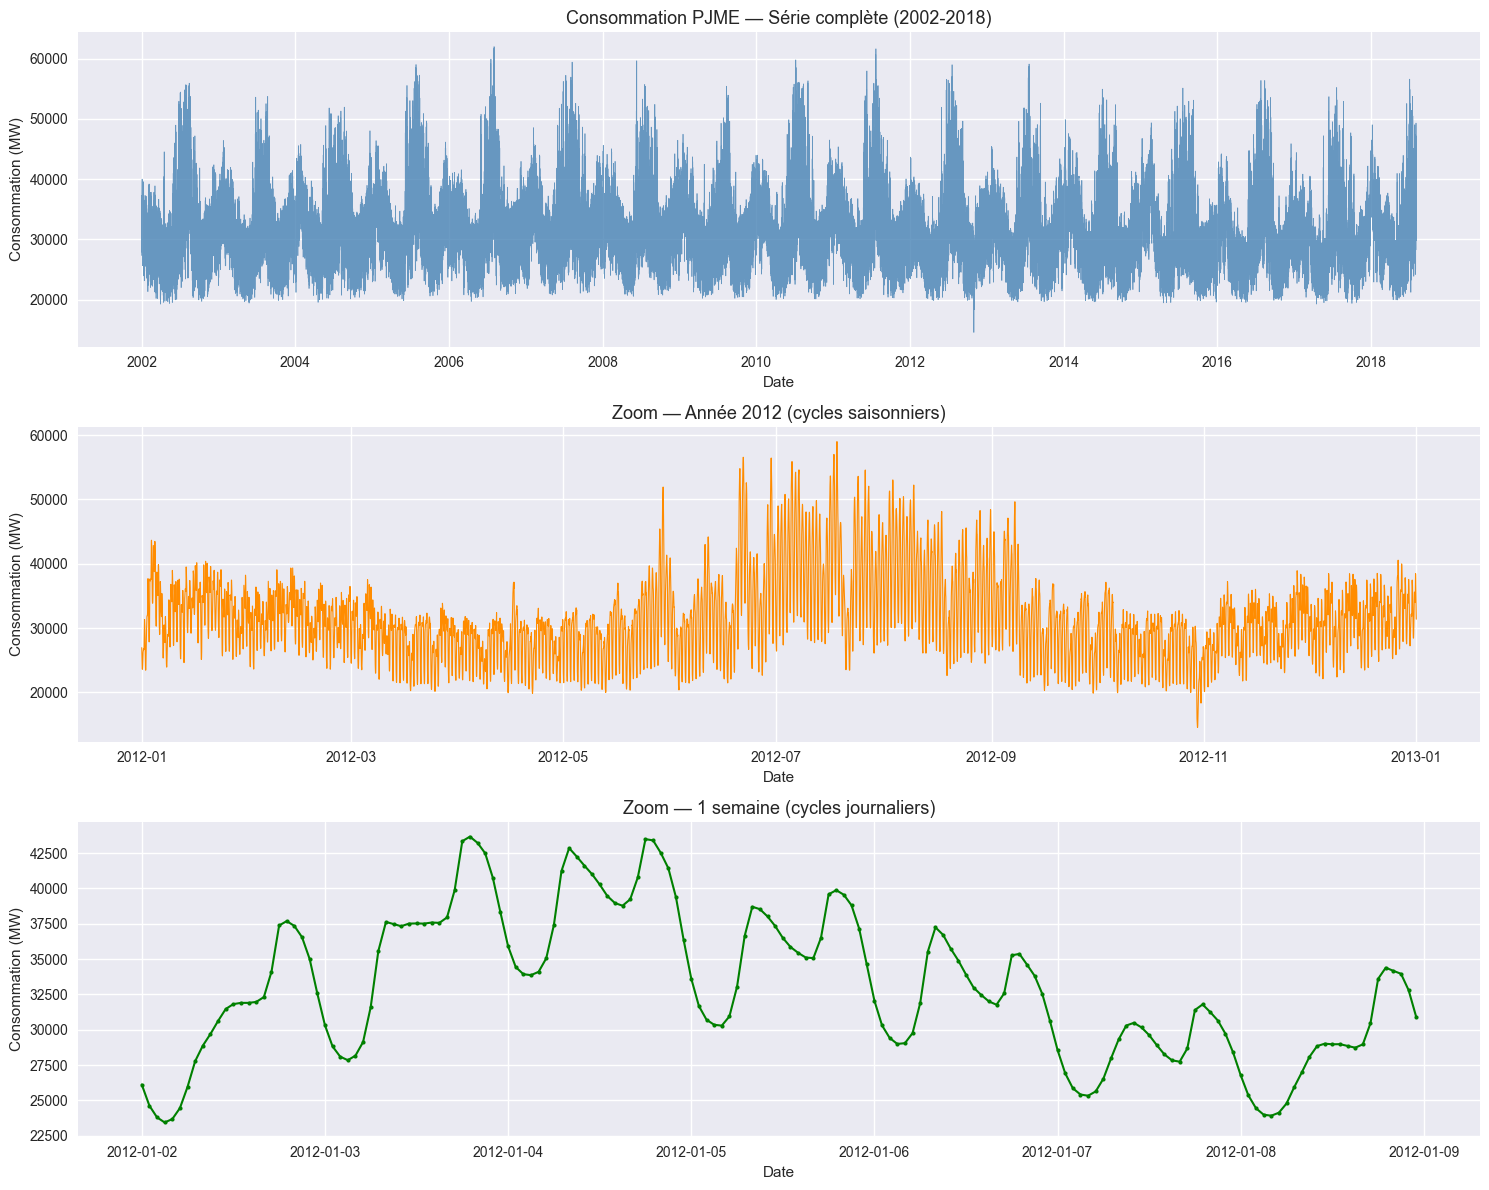

In [8]:
# ============================================================
# Visualisation de la série complète
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# --- Graphique 1 : série complète ---
axes[0].plot(df_pjme.index, df_pjme['PJME'], 
             color='steelblue', linewidth=0.5, alpha=0.8)
axes[0].set_title('Consommation PJME — Série complète (2002-2018)', fontsize=13)
axes[0].set_ylabel('Consommation (MW)')
axes[0].set_xlabel('Date')

# --- Graphique 2 : zoom sur 1 an (2012) ---
df_2012 = df_pjme.loc['2012-01-01':'2012-12-31']
axes[1].plot(df_2012.index, df_2012['PJME'], 
             color='darkorange', linewidth=0.8)
axes[1].set_title('Zoom — Année 2012 (cycles saisonniers)', fontsize=13)
axes[1].set_ylabel('Consommation (MW)')
axes[1].set_xlabel('Date')

# --- Graphique 3 : zoom sur 1 semaine (janvier 2012) ---
df_semaine = df_pjme.loc['2012-01-02':'2012-01-08']
axes[2].plot(df_semaine.index, df_semaine['PJME'], 
             color='green', linewidth=1.5, marker='o', markersize=3)
axes[2].set_title('Zoom — 1 semaine (cycles journaliers)', fontsize=13)
axes[2].set_ylabel('Consommation (MW)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

## Analyse des patterns temporels

Les visualisations confirment trois niveaux de cycles (cycle journalier, cycle hebdomadaire, cycle annuel). On va maintenant 
les **quantifier statistiquement** pour mieux comprendre leur amplitude.

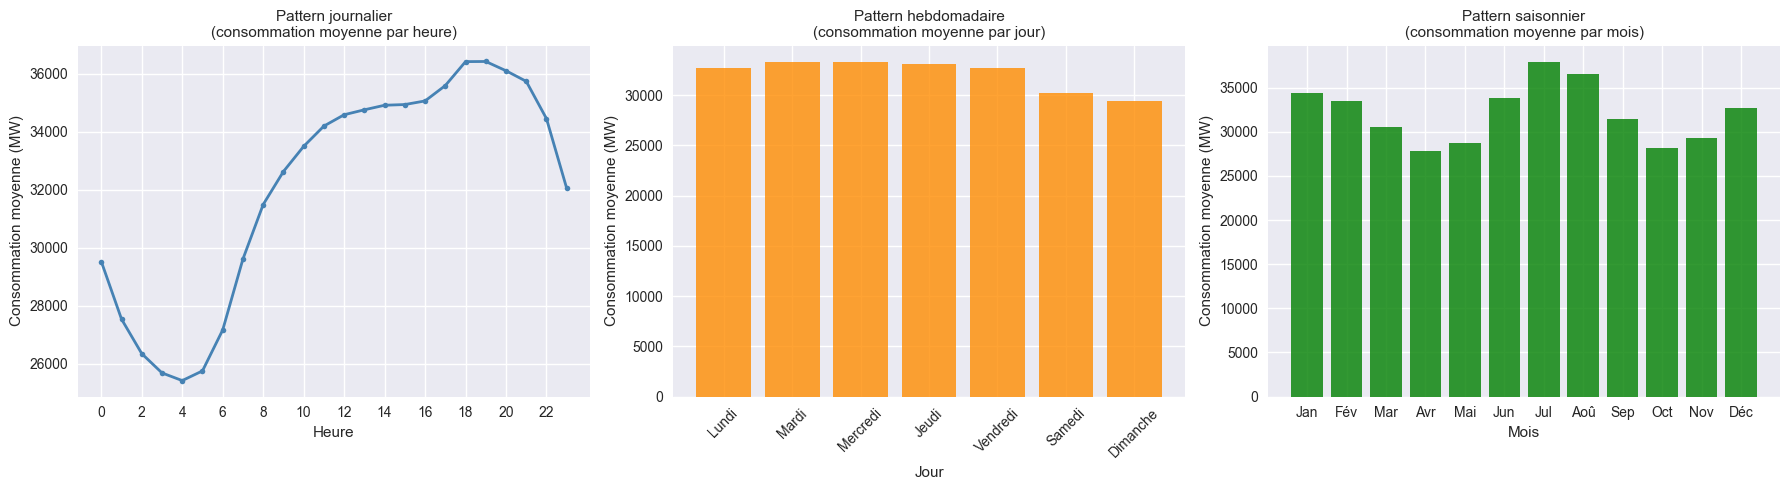

In [9]:
# ============================================================
# Analyse des patterns temporels
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Pattern journalier : consommation moyenne par heure ---
df_pjme['hour'] = df_pjme.index.hour
hourly = df_pjme.groupby('hour')['PJME'].mean()

axes[0].plot(hourly.index, hourly.values, color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].set_title('Pattern journalier\n(consommation moyenne par heure)', fontsize=11)
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Consommation moyenne (MW)')
axes[0].set_xticks(range(0, 24, 2))

# --- Pattern hebdomadaire : consommation moyenne par jour ---
df_pjme['dayofweek'] = df_pjme.index.dayofweek
jours = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
weekly = df_pjme.groupby('dayofweek')['PJME'].mean()

axes[1].bar(jours, weekly.values, color='darkorange', alpha=0.8)
axes[1].set_title('Pattern hebdomadaire\n(consommation moyenne par jour)', fontsize=11)
axes[1].set_xlabel('Jour')
axes[1].set_ylabel('Consommation moyenne (MW)')
axes[1].tick_params(axis='x', rotation=45)

# --- Pattern saisonnier : consommation moyenne par mois ---
df_pjme['month'] = df_pjme.index.month
mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 
        'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
monthly = df_pjme.groupby('month')['PJME'].mean()

axes[2].bar(mois, monthly.values, color='green', alpha=0.8)
axes[2].set_title('Pattern saisonnier\n(consommation moyenne par mois)', fontsize=11)
axes[2].set_xlabel('Mois')
axes[2].set_ylabel('Consommation moyenne (MW)')

plt.tight_layout()
plt.show()

Ces graphique confirme nos dires, on vois pour :
- patter journalier (bleu) creux à 4h du matin (tout le monde dort) avec une montée progressive dès 6h (réveil, industrie qui démarre) puis un pic à 18h-19h (retour à la maison, cuisine, chauffage/clim).
- pattern hebdomadaire (orange) de lundi à vendredi quasi identiques (~32,000 MW) tandis que samedi et dimanche nettement plus bas (~30,000-29,500 MW).L'écart semaine/weekend est visible mais modéré, on peut déja émettre l'hypothèse que l'industrie est le principal driver.
- pattern saisonnier (vert), on remarque deux pics important, janvier (chauffage hivernal) et juillet-août (climatisation estivale) et creux en mars et octobre-novembre. Juillet est le mois le plus consommateur (~37,500 MW), la climatisation dépasse donc le chauffage en terme de consommation énergétique.

## Détection des valeurs aberrantes

Avant de passer au feature engineering, on va d'abord vérifié s'il existe des valeurs aberrantes (outliers) dans la série. L'objectif est de les traitées pour ne pas biaiser l'entraînement des modèles.

On va tester et comparer deux approches :
1. **IQR (k=3)** : méthode statistique classique, simple et robuste
2. **STL Decomposition** : méthode spécifique aux séries temporelles, 
   qui tient compte de la saisonnalité avant de juger qu'une valeur est aberrante

Le but de la comparaison est de choisi l'approche la plus interessante.

In [10]:
# ============================================================
# Méthode 1 : IQR (k=3)
# ============================================================

Q1 = df_pjme['PJME'].quantile(0.25)
Q3 = df_pjme['PJME'].quantile(0.75)
IQR = Q3 - Q1

borne_basse_iqr = Q1 - 3 * IQR
borne_haute_iqr = Q3 + 3 * IQR

outliers_iqr = df_pjme[
    (df_pjme['PJME'] < borne_basse_iqr) | 
    (df_pjme['PJME'] > borne_haute_iqr)
]

print(f"=== MÉTHODE IQR ===")
print(f"Borne basse : {borne_basse_iqr:,.0f} MW")
print(f"Borne haute : {borne_haute_iqr:,.0f} MW")
print(f"Outliers détectés : {len(outliers_iqr)}")
print(f"\nDistribution par mois :")
print(outliers_iqr.groupby(outliers_iqr.index.month)['PJME'].count())

=== MÉTHODE IQR ===
Borne basse : 3,342 MW
Borne haute : 59,881 MW
Outliers détectés : 27

Distribution par mois :
Datetime
7    10
8    17
Name: PJME, dtype: int64


On remarque une observation importante, tous les outliers IQR sont en juillet et août. Ça sent la confusion entre pic saisonnier légitime et vraie anomalie. On va voir ce que STL donne pour comparer.

=== MÉTHODE STL ===
Borne basse résidu : -8,048 MW
Borne haute résidu : 8,125 MW
Outliers détectés  : 191

Distribution par mois :
Datetime
1     15
2      9
3      2
4      2
5     12
6     38
7     42
8     44
9     20
10     5
12     2
Name: resid, dtype: int64


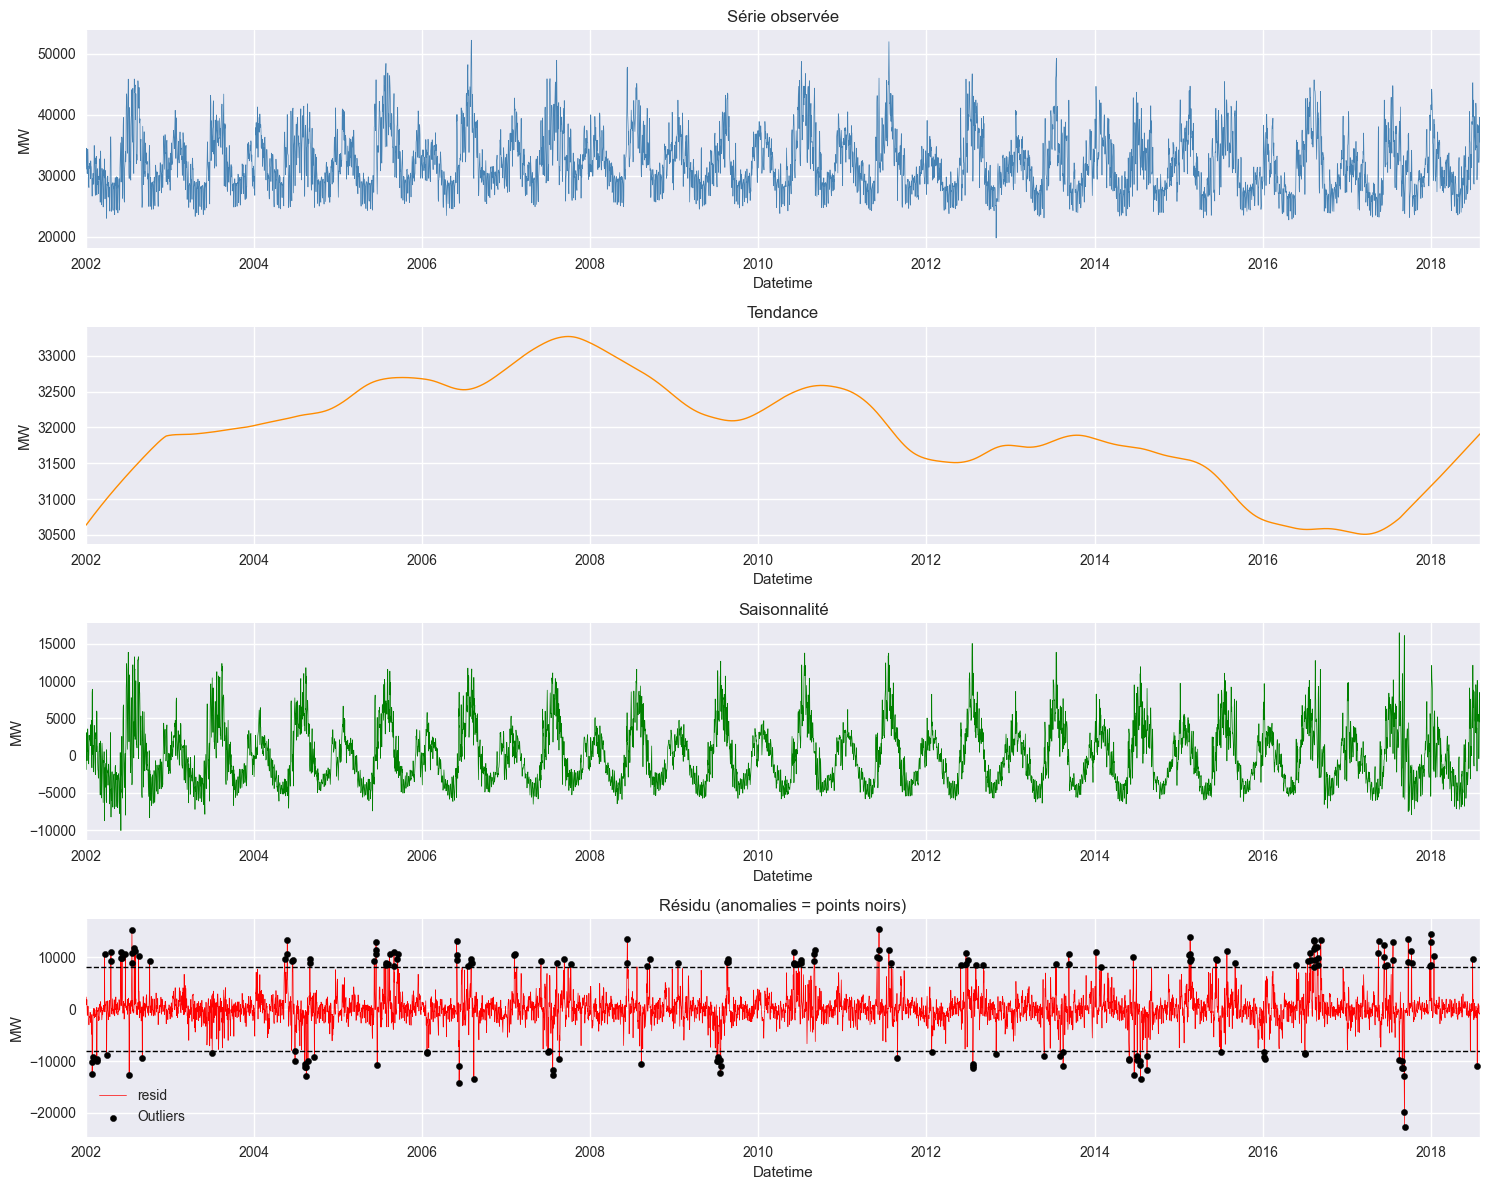

In [ ]:
# ============================================================
# Méthode 2 : STL Decomposition
# ============================================================

from statsmodels.tsa.seasonal import STL

# STL décompose la série en : tendance + saisonnalité + résidu
# period=24*7 = une semaine en heures (cycle hebdomadaire)
# On utilise un résample journalier pour accélérer le calcul
df_daily = df_pjme['PJME'].resample('D').mean()

stl = STL(df_daily, period=365, robust=True)
result = stl.fit()

# Le résidu = ce qui reste après avoir enlevé tendance + saisonnalité
residu = result.resid

# On détecte les outliers sur le résidu avec IQR standard (k=3)
Q1_r = residu.quantile(0.25)
Q3_r = residu.quantile(0.75)
IQR_r = Q3_r - Q1_r

borne_basse_stl = Q1_r - 3 * IQR_r
borne_haute_stl = Q3_r + 3 * IQR_r

outliers_stl = residu[
    (residu < borne_basse_stl) | 
    (residu > borne_haute_stl)
]

print(f"=== MÉTHODE STL ===")
print(f"Borne basse résidu : {borne_basse_stl:,.0f} MW")
print(f"Borne haute résidu : {borne_haute_stl:,.0f} MW")
print(f"Outliers détectés  : {len(outliers_stl)}")
print(f"\nDistribution par mois :")
print(outliers_stl.groupby(outliers_stl.index.month).count())

# Visualisation de la décomposition STL
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

result.observed.plot(ax=axes[0], color='steelblue', linewidth=0.5)
axes[0].set_title('Série observée')
axes[0].set_ylabel('MW')

result.trend.plot(ax=axes[1], color='darkorange', linewidth=1)
axes[1].set_title('Tendance')
axes[1].set_ylabel('MW')

result.seasonal.plot(ax=axes[2], color='green', linewidth=0.5)
axes[2].set_title('Saisonnalité')
axes[2].set_ylabel('MW')

result.resid.plot(ax=axes[3], color='red', linewidth=0.5)
axes[3].axhline(y=borne_basse_stl, color='black', linestyle='--', linewidth=1)
axes[3].axhline(y=borne_haute_stl, color='black', linestyle='--', linewidth=1)
axes[3].scatter(outliers_stl.index, outliers_stl.values, 
                color='black', s=20, zorder=5, label='Outliers')
axes[3].set_title('Résidu (anomalies = points noirs)')
axes[3].set_ylabel('MW')
axes[3].legend()
plt.tight_layout()
plt.show()

**Comparaison des 2 méthodes**
- IQR est trop aveugle : Les 27 outliers sont tous en juillet-août. Ce sont très probablement des pics de canicule légitimes, pas de vraies anomalies. L'IQR ne sait pas que 58,000 MW en août c'est normal pour cette région.
- STL est plus parlant mais trop sensible : 191 outliers répartis sur tous les mois. La décomposition a bien retiré la saisonnalité avant de juger. Mais 191 outliers sur 16 ans ça représente ~0.13% des données journalière ce qui est quand meme c'est raisonnable.
De plus la tendance (graphique orange) est très intéressante, on note un  pic en 2008 (avant la crise financière qui a réduit l'activité industrielle) puis baisse progressive jusqu'en 2016.

STL est clairement la meilleure approche pour notre cas. Elle détecte des vraies anomalies plutôt que de confondre des pics saisonniers normaux avec des outliers.

## Traitement des outliers 

On conserve les 191 outliers détectés par STL mais on les **signale** avec une feature binaire `is_outlier`. Cela permettra aux modèles de distinguer les points atypiques (canicules, ouragans, événements exceptionnels) sans perdre l'information qu'ils contiennent.

- `is_outlier = 1` donc point atypique détecté par STL
- `is_outlier = 0` donc point normal

In [13]:
# ============================================================
# Création de la feature is_outlier
# ============================================================

# Les outliers STL sont sur des données journalières
# On reporte l'information sur les données horaires
outliers_dates = outliers_stl.index.date

df_pjme['is_outlier'] = df_pjme.index.date
df_pjme['is_outlier'] = df_pjme['is_outlier'].apply(
    lambda x: 1 if x in outliers_dates else 0
)

print("=== RÉSUMÉ ===")
print(f"Heures normales  : {(df_pjme['is_outlier'] == 0).sum():,}")
print(f"Heures outliers  : {(df_pjme['is_outlier'] == 1).sum():,}")
print(f"Pourcentage      : {df_pjme['is_outlier'].mean()*100:.2f}%")

print("\n=== APERÇU DU DATAFRAME ===")
print(df_pjme.head(10))

=== RÉSUMÉ ===
Heures normales  : 140,782
Heures outliers  : 4,584
Pourcentage      : 3.15%

=== APERÇU DU DATAFRAME ===
                        PJME  hour  dayofweek  month  is_outlier
Datetime                                                        
2002-01-01 01:00:00  30393.0     1          1      1           0
2002-01-01 02:00:00  29265.0     2          1      1           0
2002-01-01 03:00:00  28357.0     3          1      1           0
2002-01-01 04:00:00  27899.0     4          1      1           0
2002-01-01 05:00:00  28057.0     5          1      1           0
2002-01-01 06:00:00  28654.0     6          1      1           0
2002-01-01 07:00:00  29308.0     7          1      1           0
2002-01-01 08:00:00  29595.0     8          1      1           0
2002-01-01 09:00:00  29943.0     9          1      1           0
2002-01-01 10:00:00  30692.0    10          1      1           0


## Sauvegarde des données nettoyées

On sauvegarde le dataframe dans `data/processed/` pour le réutiliser 
dans les notebooks suivants sans avoir à refaire tout le nettoyage.
On va supprimé les colonnes temporaires créées pendant l'exploration 
(hour, dayofweek, month).

In [14]:
# ============================================================
# Sauvegarde du dataframe nettoyé
# ============================================================

# Suppression des colonnes temporaires d'exploration
df_clean = df_pjme.drop(columns=['hour', 'dayofweek', 'month'])

# Sauvegarde
df_clean.to_csv('../data/processed/pjme_clean.csv')

print(" Fichier sauvegardé : data/processed/pjme_clean.csv")
print(f"Shape final : {df_clean.shape}")
print(f"\nAperçu :")
print(df_clean.head())

 Fichier sauvegardé : data/processed/pjme_clean.csv
Shape final : (145366, 2)

Aperçu :
                        PJME  is_outlier
Datetime                                
2002-01-01 01:00:00  30393.0           0
2002-01-01 02:00:00  29265.0           0
2002-01-01 03:00:00  28357.0           0
2002-01-01 04:00:00  27899.0           0
2002-01-01 05:00:00  28057.0           0
